In [5]:

import sys
sys.path.append('../')
from utils_models import *



fluxonium = scqubits.Fluxonium(EJ=2.7,
                        EC=0.6,
                        EL=0.13,
                        flux=0,cutoff=110,
                        truncated_dim=20)
tune_tmon = scqubits.TunableTransmon(
    EJmax=50.0,
    EC=0.5,
    d=0.01,
    flux=0.403471,
    ng=0.0,
    ncut=30,
    truncated_dim = 4
    )

system = FluxoniumTunableTransmonSystem(
    
    fluxonium  = fluxonium,
    tune_tmon = tune_tmon,
    computaional_states = '1,2',
    g_strength = 0.2,
    )
    
energies=  system.hilbertspace.eigenvals(system.fluxonium.truncated_dim * system.tune_tmon.truncated_dim )


def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]


ols = system.tune_tmon.truncated_dim


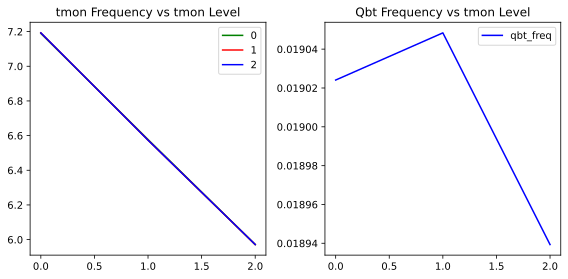

In [8]:


def plot_frequencies_qbt_osc(dressed_ener: Callable, tls):
    colors = ['green', 'red', 'blue', 'orange']

    # Create a figure and a set of subplots
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))  # Adjusted for better spacing

    # Second subplot for oscillator frequencies
    for ql in [0, 1, 2]:
        osc_energies = []
        for ol in range(0, tls - 1):
            osc_energies.append(dressed_ener(ql, ol + 1) - dressed_ener(ql, ol))
        axs[0].plot(list(range(tls - 1)), osc_energies, label=f'{ql}', color=colors[ql])
    axs[0].set_title('tmon Frequency vs tmon Level')
    axs[0].legend()



    qbt_energies = []
    for ol in range(tls-1):
        qbt_energies.append(dressed_ener(2, ol) - dressed_ener(1, ol))
    axs[1].plot(list(range(tls-1)), qbt_energies, label=f'qbt_freq', color=colors[ql])
    axs[1].set_title('Qbt Frequency vs tmon Level')
    axs[1].legend()

    # Show the plots
    plt.tight_layout()  # Adjust the layout to make room for the legend
    plt.show()
    
    

plot_frequencies_qbt_osc(dressed_ener, ols)

In [9]:
dressed_ener(0,  1) - dressed_ener(0, 0),dressed_ener(1,  1) - dressed_ener(1, 0),dressed_ener(2,  1) - dressed_ener(2, 0)

(7.189448463544889, 7.192654171457119, 7.192678473811938)

In [8]:
import sys
sys.path.append('../')
from utils_models import *

In [10]:

with open(f'../pickles/transmon_response.pkl', 'rb') as file:
    results = pickle.load(file)

In [11]:
w_t_ori = 7.190996762003433
freqs = np.linspace(w_t_ori - 4e-3,w_t_ori + 4e-3,100)

pn_exp = [[] for _ in [0,1,2]]
result_counter = 0
for initial_i in [0,1,2]:
    for freq in freqs:
        pn_exp[initial_i].append(np.max(results[result_counter].expect[0]))
        result_counter += 1

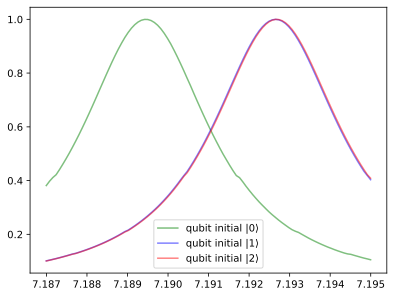

In [12]:
colors = ['green','blue','red','darkorange']
for i in [0,1,2]:
    plt.plot(freqs,pn_exp[i],color = colors[i],alpha = 0.5,label = rf'qubit initial $ | {i} \rangle$')
plt.legend()
# plt.xlim(7.1600,7.171)